# Hyperparameter Tunning

#### imports

In [1]:
from transfer_learning_model import TransferLearningModel, DroneLoss, train, predict, predict_locations, validate
from DroneDataset import DroneDataset, read_annotations
import torch
import torch.nn as nn
import torch.optim as optim
from preprocess import preprocess

In [1]:
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [3]:
import matplotlib.pyplot as plt

In [6]:
train_metrics = [
        "train_precision", "train_recall", "train_f1", "train_mAP50"
        ]
val_metrics = ["val_precision", "val_recall","val_f1", "val_mAP50"] 

### preprocess

In [2]:
#preprocess datasets

preprocess("train", "train_max_size256", 256)

0 images preprocessed
500 images preprocessed
1000 images preprocessed
1500 images preprocessed
2000 images preprocessed
2500 images preprocessed
3000 images preprocessed
3500 images preprocessed
4000 images preprocessed
4500 images preprocessed
5000 images preprocessed
5500 images preprocessed
6000 images preprocessed
6500 images preprocessed
7000 images preprocessed
7500 images preprocessed
8000 images preprocessed
8500 images preprocessed
9000 images preprocessed
9500 images preprocessed
10000 images preprocessed
10500 images preprocessed
11000 images preprocessed
11500 images preprocessed
Finished


In [3]:
preprocess("valid", "valid_max_size256", 256)

0 images preprocessed
500 images preprocessed
1000 images preprocessed
1500 images preprocessed
2000 images preprocessed
2500 images preprocessed
3000 images preprocessed
3500 images preprocessed
Finished


In [4]:
preprocess("test", "test_max_size256", 256)

0 images preprocessed
500 images preprocessed
1000 images preprocessed
1500 images preprocessed
2000 images preprocessed
2500 images preprocessed
Finished


### empty cache

In [5]:
import gc

gc.collect()
torch.cuda.empty_cache()

print(torch.cuda.memory_allocated() / 1024**3, "GB allocated")
print(torch.cuda.memory_reserved() / 1024**3, "GB reserved")

0.0 GB allocated
0.0 GB reserved


## Load dataset

In [6]:
train_set = DroneDataset(*read_annotations("train_max_size256"))

In [7]:
validation_set = DroneDataset(*read_annotations("valid_max_size256"))

## Experiments

#### Experiment 1

In [ ]:
# experiment 1

hyperparameter_combinations = {
    "detection_layers": [ [ [512, 256, 3, 1, 1, "zeros"], [256, 128, 3, 1, 1, "zeros"], [128, 64, 3, 1, 1, "zeros"] ] ],
    "activation_func": [nn.ReLU],
    "dropout_rate": [0.0],
    "positive_class_bce_coefficient": [0.5],
    "localization_loss_coefficent": [1],
    "bbox_loss_func": [nn.SmoothL1Loss],

    "fine_tune_layers_num": [0],

    "optimizer": [optim.Adam],
    "optimizer_kwargs": [{"lr": 0.001,}],

    "first_max_num_epochs": [60],
    "second_max_num_epochs": [0],
    "patience": [3],

    "objectness_threshold": [0.10, 0.30, 0.50, 0.70, 0.90, 0.95],

    "batch_size": [16],

    "early_stop_step1": [True],
    
    "early_stop_step2": [False]
}

validate(train_set, validation_set, hyperparameter_combinations, False, "experiment_1.json")

combination validated


In [31]:
experiment1 = pd.read_json("experiment_1.json")


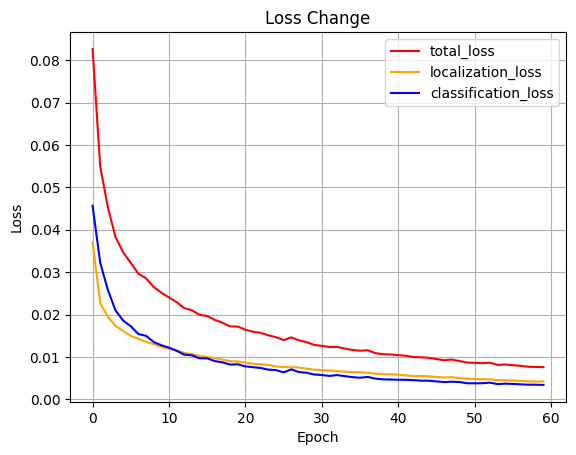

In [56]:
total_loss_list = experiment1.head(1)["total_loss_list1"].tolist()[0]
localization_loss_list = experiment1.head(1)["class_loss_list1"].tolist()[0]
classification_loss_list = experiment1.head(1)["localization_loss_list1"].tolist()[0]

epochs = range(len(total_loss_list))

plt.plot(epochs, total_loss_list, linestyle="-", color="red", label="total_loss")
plt.plot(epochs, localization_loss_list, linestyle="-", color="orange", label="localization_loss")
plt.plot(epochs, classification_loss_list, linestyle="-", color="blue", label="classification_loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Change")

plt.legend()
plt.grid()
plt.show()

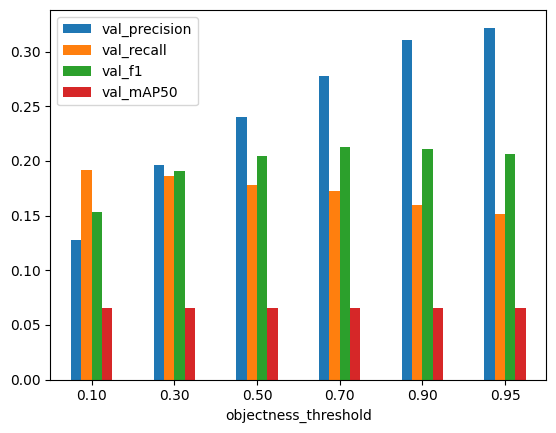

In [36]:
# threshold affect

ax =experiment1.plot(x="objectness_threshold", 
                 y= ['val_precision', 'val_recall', 'val_f1', 'val_mAP50'],
                 kind="bar")

# format x axis

ax.set_xticklabels([f"{x:.2f}" for x in experiment1["objectness_threshold"]],rotation=0)

plt.show()

#### Experiment 2

In [8]:
# experiment 2

hyperparameter_combinations = {
    "detection_layers": [ [ [512, 256, 3, 1, 1, "zeros"], [256, 128, 3, 1, 1, "zeros"], [128, 64, 3, 1, 1, "zeros"] ] ],
    "activation_func": [nn.ReLU],
    "dropout_rate": [0.0],
    "positive_class_bce_coefficient": [0.5],
    "localization_loss_coefficent": [1],
    "bbox_loss_func": [nn.SmoothL1Loss],

    "fine_tune_layers_num": [0],

    "optimizer": [optim.Adam],
    "optimizer_kwargs": [{"lr": 0.001,}],

    "first_max_num_epochs": [120],
    "second_max_num_epochs": [0],
    "patience": [3],

    "objectness_threshold": [0.10, 0.30, 0.50, 0.70, 0.90, 0.95],

    "batch_size": [16],

    "early_stop_step1": [True],
    
    "early_stop_step2": [False]
}

validate(train_set, validation_set, hyperparameter_combinations, False, "experiment_2.json")

combination validated


In [3]:
experiment2 = pd.read_json("experiment_2.json")


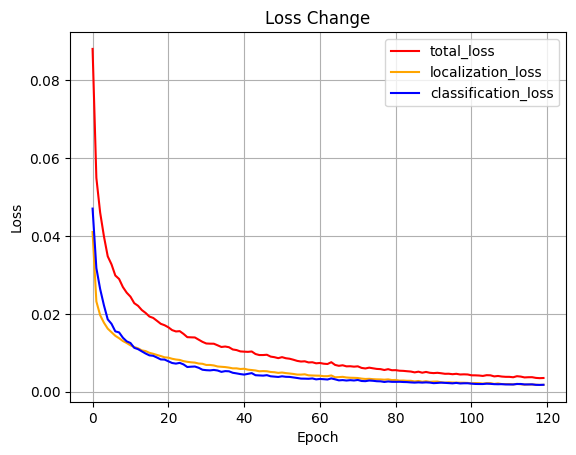

In [49]:
total_loss_list = experiment2.head(1)["total_loss_list1"].tolist()[0]
localization_loss_list = experiment2.head(1)["class_loss_list1"].tolist()[0]
classification_loss_list = experiment2.head(1)["localization_loss_list1"].tolist()[0]

epochs = range(len(total_loss_list))

plt.plot(epochs, total_loss_list, linestyle="-", color="red", label="total_loss")
plt.plot(epochs, localization_loss_list, linestyle="-", color="orange", label="localization_loss")
plt.plot(epochs, classification_loss_list, linestyle="-", color="blue", label="classification_loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Change")

plt.legend()
plt.grid()
plt.show()

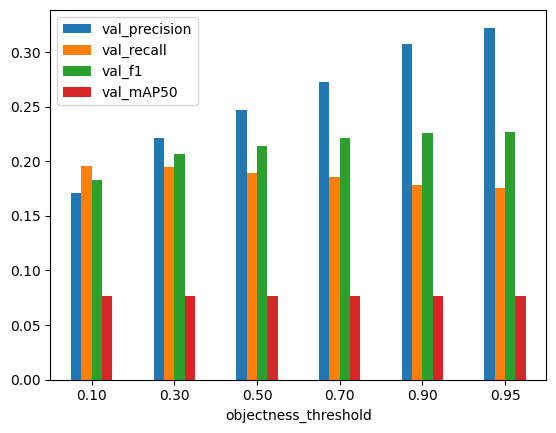

In [35]:
ax =experiment2.plot(x="objectness_threshold", 
                 y= ['val_precision', 'val_recall', 'val_f1', 'val_mAP50'],
                 kind="bar")

# format x axis

ax.set_xticklabels([f"{x:.2f}" for x in experiment2["objectness_threshold"]],rotation=0)

plt.show()

### Experiment 1 vs Experiment 2

In [40]:
print("---------experiment 1-------------")

print(f"max train_f1 : {experiment1['train_f1'].max():.4f}")
print(f"max train_precision: {experiment1['train_precision'].max():.4f}")
print(f"max train_recall: {experiment1['train_recall'].max():.4f}")
print(f"max train_mAP50: {experiment1['train_mAP50'].max():.4f}")

print()

print(f"max val_f1: {experiment1['val_f1'].max():.4f}")
print(f"max val_precision: {experiment1['val_precision'].max():.4f}")
print(f"max val_recall: {experiment1['val_recall'].max():.4f}")
print(f"max val_mAP50: {experiment1['val_mAP50'].max():.4f}")

print()

print("------- experiment 2 -------")

print(f"max train_f1 : {experiment2['train_f1'].max():.4f}")
print(f"max train_precision: {experiment2['train_precision'].max():.4f}")
print(f"max train_recall: {experiment2['train_recall'].max():.4f}")
print(f"max train_mAP50: {experiment2['train_mAP50'].max():.4f}")

print()

print(f"max val_f1: {experiment2['val_f1'].max():.4f}")
print(f"max val_precision: {experiment2['val_precision'].max():.4f}")
print(f"max val_recall: {experiment2['val_recall'].max():.4f}")
print(f"max val_mAP50: {experiment2['val_mAP50'].max():.4f}")

print()

---------experiment 1-------------
max train_f1 : 0.3881
max train_precision: 0.4765
max train_recall: 0.3585
max train_mAP50: 0.1831

max val_f1: 0.2129
max val_precision: 0.3220
max val_recall: 0.1920
max val_mAP50: 0.0658

------- experiment 2 -------
max train_f1 : 0.4670
max train_precision: 0.5110
max train_recall: 0.4430
max train_mAP50: 0.2665

max val_f1: 0.2270
max val_precision: 0.3224
max val_recall: 0.1958
max val_mAP50: 0.0762



#### Experiment 3

In [21]:
# experiment 3

hyperparameter_combinations = {
    "detection_layers": [ 
        [ [512, 256, 3, 1, 1, "zeros"] ], 
        [ [512, 256, 3, 1, 1, "zeros"], [256, 128, 3, 1, 1, "zeros"] ] 
                         ],
    "activation_func": [nn.ReLU],
    "dropout_rate": [0.0],
    "positive_class_bce_coefficient": [0.5],
    "localization_loss_coefficent": [1],
    "bbox_loss_func": [nn.SmoothL1Loss],

    "fine_tune_layers_num": [0],

    "optimizer": [optim.Adam],
    "optimizer_kwargs": [{"lr": 0.001,}, {"lr": 0.01}],

    "first_max_num_epochs": [120],
    "second_max_num_epochs": [0],
    "patience": [3],

    "objectness_threshold": [0.10, 0.30, 0.50, 0.70, 0.90, 0.95],

    "batch_size": [16],

    "early_stop_step1": [True],
    
    "early_stop_step2": [False]
}

validate(train_set, validation_set, hyperparameter_combinations, False, "experiment_3.json")

combination validated
combination validated
combination validated
combination validated


In [2]:
experiment3 = pd.read_json("experiment_3.json")

In [ ]:

print("------- experiment 2 -------")
print(f"max train_f1 : {experiment2['train_f1'].max():.4f}")
print(f"max train_precision: {experiment2['train_precision'].max():.4f}")
print(f"max train_recall: {experiment2['train_recall'].max():.4f}")
print(f"max train_mAP50: {experiment2['train_mAP50'].max():.4f}")

print()

print(f"max val_f1: {experiment2['val_f1'].max():.4f}")
print(f"max val_precision: {experiment2['val_precision'].max():.4f}")
print(f"max val_recall: {experiment2['val_recall'].max():.4f}")
print(f"max val_mAP50: {experiment2['val_mAP50'].max():.4f}")

print("------- experiment 3 -------")

print(f"max train_f1 : {experiment3['train_f1'].max():.4f}")
print(f"max train_precision: {experiment3['train_precision'].max():.4f}")
print(f"max train_recall: {experiment3['train_recall'].max():.4f}")
print(f"max train_mAP50: {experiment3['train_mAP50'].max():.4f}")

print()

print(f"max val_f1: {experiment3['val_f1'].max():.4f}")
print(f"max val_precision: {experiment3['val_precision'].max():.4f}")
print(f"max val_recall: {experiment3['val_recall'].max():.4f}")
print(f"max val_mAP50: {experiment3['val_mAP50'].max():.4f}")

max train_f1 : 0.4670
max train_precision: 0.5110
max train_recall: 0.4430
max train_mAP50: 0.2665

max val_f1: 0.2270
max val_precision: 0.3224
max val_recall: 0.1958
max val_mAP50: 0.0762
------- experiment 3 -------
max train_f1 : 0.4228
max train_precision: 0.5161
max train_recall: 0.4027
max train_mAP50: 0.2116

max val_f1: 0.2046
max val_precision: 0.3068
max val_recall: 0.1770
max val_mAP50: 0.0605


#### Experiment 4

In [36]:
# experiment 4

hyperparameter_combinations = {
    "detection_layers": [ [ [512, 256, 3, 1, 1, "zeros"], [256, 128, 3, 1, 1, "zeros"], [128, 64, 3, 1, 1, "zeros"] ] ],
    "activation_func": [nn.ReLU],
    "dropout_rate": [0.0],
    "positive_class_bce_coefficient": [0.5],
    "localization_loss_coefficent": [1],
    "bbox_loss_func": [nn.SmoothL1Loss],

    "fine_tune_layers_num": [2, 1],

    "optimizer": [optim.Adam],
    "optimizer_kwargs": [{"lr": 0.001}],

    "first_max_num_epochs": [60],
    "second_max_num_epochs": [60],
    "patience": [3],

    "objectness_threshold": [0.10, 0.30, 0.50, 0.70, 0.90, 0.95],

    "batch_size": [16],

    "early_stop_step1": [False],
    
    "early_stop_step2": [True]
}

validate(train_set, validation_set, hyperparameter_combinations, True, "experiment_4.json")

combination validated
combination validated


In [34]:
experiment4 = pd.read_json("experiment_4.json")

In [51]:
print("------- experiment 2 -------")

print(f"max train_f1 : {experiment2['train_f1'].max():.4f}")
print(f"max train_precision: {experiment2['train_precision'].max():.4f}")
print(f"max train_recall: {experiment2['train_recall'].max():.4f}")
print(f"max train_mAP50: {experiment2['train_mAP50'].max():.4f}")

print()

print(f"max val_f1: {experiment2['val_f1'].max():.4f}")
print(f"max val_precision: {experiment2['val_precision'].max():.4f}")
print(f"max val_recall: {experiment2['val_recall'].max():.4f}")
print(f"max val_mAP50: {experiment2['val_mAP50'].max():.4f}")

print("------- experiment 4 -------")

print(f"max train_f1 : {experiment4['train_f1'].max():.4f}")
print(f"max train_precision: {experiment4['train_precision'].max():.4f}")
print(f"max train_recall: {experiment4['train_recall'].max():.4f}")
print(f"max train_mAP50: {experiment4['train_mAP50'].max():.4f}")

print()

print(f"max val_f1: {experiment4['val_f1'].max():.4f}")
print(f"max val_precision: {experiment4['val_precision'].max():.4f}")
print(f"max val_recall: {experiment4['val_recall'].max():.4f}")
print(f"max val_mAP50: {experiment4['val_mAP50'].max():.4f}")

------- experiment 2 -------
max train_f1 : 0.4670
max train_precision: 0.5110
max train_recall: 0.4430
max train_mAP50: 0.2665

max val_f1: 0.2270
max val_precision: 0.3224
max val_recall: 0.1958
max val_mAP50: 0.0762
------- experiment 4 -------
max train_f1 : 0.6447
max train_precision: 0.6865
max train_recall: 0.6169
max train_mAP50: 0.4813

max val_f1: 0.3680
max val_precision: 0.4523
max val_recall: 0.3515
max val_mAP50: 0.1934


#### experiment 5

In [35]:
# experiment 5

hyperparameter_combinations = {
    "detection_layers": [ [ [512, 256, 3, 1, 1, "zeros"], [256, 128, 3, 1, 1, "zeros"], [128, 64, 3, 1, 1, "zeros"] ] ],
    "activation_func": [nn.ReLU],
    "dropout_rate": [0.3, 0.5],
    "positive_class_bce_coefficient": [0.5],
    "localization_loss_coefficent": [1],
    "bbox_loss_func": [nn.SmoothL1Loss],

    "fine_tune_layers_num": [0],

    "optimizer": [optim.Adam],
    "optimizer_kwargs": [{"lr": 0.001}],

    "first_max_num_epochs": [120],
    "second_max_num_epochs": [0],
    "patience": [3],

    "objectness_threshold": [0.10, 0.30, 0.50, 0.70, 0.90, 0.95],

    "batch_size": [16],

    "early_stop_step1": [False],
    
    "early_stop_step2": [True]
}

validate(train_set, validation_set, hyperparameter_combinations, False, "experiment_5.json")

combination validated
combination validated


In [52]:
experiment5 = pd.read_json("experiment_5.json")

In [53]:
experiment5.head(24)

,detection_layers,activation_func,dropout_rate,positive_class_bce_coefficient,localization_loss_coefficent,bbox_loss_func,fine_tune,fine_tune_layers_num,optimizer,optimizer_kwargs,first_max_num_epochs,second_max_num_epochs,patience,objectness_threshold,batch_size,early_stop_step1,early_stop_step2,total_train_loss,train_classification_loss,total_localization_loss,total_loss_list1,class_loss_list1,localization_loss_list1,total_loss_list2,class_loss_list2,localization_loss_list2,train_TP,train_FP,train_FN,train_precision,train_recall,train_f1,train_mAP50,val_TP,val_FP,val_FN,val_precision,val_recall,val_f1,val_mAP50
0,"[[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...",ReLU,0.3,0.5,1,SmoothL1Loss,False,0,Adam,{'lr': 0.001},120,0,3,0.10,16,False,True,0.011775,0.006652,0.005123,"[0.08499219950285901, 0.059578447545406005, 0....","[0.037512254375390006, 0.023958925713875003, 0...","[0.04747994526520401, 0.035619521798062, 0.029...",[],[],[],2389,10644,4627,0.183304,0.340507,0.238316,0.196768,623,5766,2569,0.097511,0.195175,0.130049,0.079921
1,"[[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...",ReLU,0.3,0.5,1,SmoothL1Loss,False,0,Adam,{'lr': 0.001},120,0,3,0.30,16,False,True,0.011775,0.006652,0.005123,"[0.08499219950285901, 0.059578447545406005, 0....","[0.037512254375390006, 0.023958925713875003, 0...","[0.04747994526520401, 0.035619521798062, 0.029...",[],[],[],2355,4517,4661,0.342695,0.335661,0.339142,0.196768,601,2257,2591,0.210287,0.188283,0.198678,0.079921
2,"[[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...",ReLU,0.3,0.5,1,SmoothL1Loss,False,0,Adam,{'lr': 0.001},120,0,3,0.50,16,False,True,0.011775,0.006652,0.005123,"[0.08499219950285901, 0.059578447545406005, 0....","[0.037512254375390006, 0.023958925713875003, 0...","[0.04747994526520401, 0.035619521798062, 0.029...",[],[],[],2331,3230,4685,0.419169,0.332241,0.370677,0.196768,577,1456,2615,0.283817,0.180764,0.220861,0.079921
3,"[[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...",ReLU,0.3,0.5,1,SmoothL1Loss,False,0,Adam,{'lr': 0.001},120,0,3,0.70,16,False,True,0.011775,0.006652,0.005123,"[0.08499219950285901, 0.059578447545406005, 0....","[0.037512254375390006, 0.023958925713875003, 0...","[0.04747994526520401, 0.035619521798062, 0.029...",[],[],[],2299,2750,4717,0.455338,0.327680,0.381102,0.196768,560,1161,2632,0.325392,0.175439,0.227967,0.079921
4,"[[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...",ReLU,0.3,0.5,1,SmoothL1Loss,False,0,Adam,{'lr': 0.001},120,0,3,0.90,16,False,True,0.011775,0.006652,0.005123,"[0.08499219950285901, 0.059578447545406005, 0....","[0.037512254375390006, 0.023958925713875003, 0...","[0.04747994526520401, 0.035619521798062, 0.029...",[],[],[],2257,2319,4759,0.493226,0.321693,0.389406,0.196768,525,894,2667,0.369979,0.164474,0.227716,0.079921
5,"[[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...",ReLU,0.3,0.5,1,SmoothL1Loss,False,0,Adam,{'lr': 0.001},120,0,3,0.95,16,False,True,0.011775,0.006652,0.005123,"[0.08499219950285901, 0.059578447545406005, 0....","[0.037512254375390006, 0.023958925713875003, 0...","[0.04747994526520401, 0.035619521798062, 0.029...",[],[],[],2218,2099,4798,0.513783,0.316135,0.391423,0.196768,507,790,2685,0.390902,0.158835,0.225885,0.079921
6,"[[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...",ReLU,0.5,0.5,1,SmoothL1Loss,False,0,Adam,{'lr': 0.001},120,0,3,0.10,16,False,True,0.015937,0.009056,0.006881,"[0.08912958999492, 0.06408209205394601, 0.0562...","[0.036919927872001004, 0.025260927559809, 0.02...","[0.052209662025087006, 0.038821164436210004, 0...",[],[],[],2212,11865,4804,0.157136,0.315279,0.209738,0.205407,637,6223,2555,0.092857,0.199561,0.126741,0.109653
7,"[[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...",ReLU,0.5,0.5,1,SmoothL1Loss,False,0,Adam,{'lr': 0.001},120,0,3,0.30,16,False,True,0.015937,0.009056,0.006881,"[0.08912958999492, 0.06408209205394601, 0.0562...","[0.036919927872001004, 0.025260927559809, 0.02...","[0.052209662025087006, 0.038821164436210004, 0...",[],[],[],2175,3658,4841,0.372878,0.310006,0.338548,0.2054

#### experiment 6

In [37]:
# experiment 6

hyperparameter_combinations = {
    "detection_layers": [ [ [512, 256, 3, 1, 1, "zeros"], [256, 128, 3, 1, 1, "zeros"], [128, 64, 3, 1, 1, "zeros"] ] ],
    "activation_func": [nn.ReLU],
    "dropout_rate": [0.0],
    "positive_class_bce_coefficient": [0.5],
    "localization_loss_coefficent": [2, 5],
    "bbox_loss_func": [nn.SmoothL1Loss],

    "fine_tune_layers_num": [0],

    "optimizer": [optim.Adam],
    "optimizer_kwargs": [{"lr": 0.001}],

    "first_max_num_epochs": [120],
    "second_max_num_epochs": [0],
    "patience": [3],

    "objectness_threshold": [0.10, 0.30, 0.50, 0.70, 0.90, 0.95],

    "batch_size": [16],

    "early_stop_step1": [False],
    
    "early_stop_step2": [True]
}

validate(train_set, validation_set, hyperparameter_combinations, False, "experiment_6.json")

combination validated
combination validated


In [38]:
experiment6 = pd.read_json("experiment_6.json")

In [40]:
experiment6.head(12)

,detection_layers,activation_func,dropout_rate,positive_class_bce_coefficient,localization_loss_coefficent,bbox_loss_func,fine_tune,fine_tune_layers_num,optimizer,optimizer_kwargs,first_max_num_epochs,second_max_num_epochs,patience,objectness_threshold,batch_size,early_stop_step1,early_stop_step2,total_train_loss,train_classification_loss,total_localization_loss,total_loss_list1,class_loss_list1,localization_loss_list1,total_loss_list2,class_loss_list2,localization_loss_list2,train_TP,train_FP,train_FN,train_precision,train_recall,train_f1,train_mAP50,val_TP,val_FP,val_FN,val_precision,val_recall,val_f1,val_mAP50
0,"[[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...",ReLU,0,0.5,2,SmoothL1Loss,False,0,Adam,{'lr': 0.001},120,0,3,0.10,16,False,True,0.005076,0.002153,0.001462,"[0.13069544255259702, 0.08754677886983801, 0.0...","[0.042070235221620005, 0.025127752409873003, 0...","[0.044312603621722006, 0.031209513138266004, 0...",[],[],[],3326,5303,3690,0.385444,0.474059,0.425184,0.288345,607,3549,2585,0.146054,0.190163,0.165215,0.069667
1,"[[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...",ReLU,0,0.5,2,SmoothL1Loss,False,0,Adam,{'lr': 0.001},120,0,3,0.30,16,False,True,0.005076,0.002153,0.001462,"[0.13069544255259702, 0.08754677886983801, 0.0...","[0.042070235221620005, 0.025127752409873003, 0...","[0.044312603621722006, 0.031209513138266004, 0...",[],[],[],3312,3944,3704,0.456450,0.472064,0.464126,0.288345,592,2353,2600,0.201019,0.185464,0.192928,0.069667
2,"[[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...",ReLU,0,0.5,2,SmoothL1Loss,False,0,Adam,{'lr': 0.001},120,0,3,0.50,16,False,True,0.005076,0.002153,0.001462,"[0.13069544255259702, 0.08754677886983801, 0.0...","[0.042070235221620005, 0.025127752409873003, 0...","[0.044312603621722006, 0.031209513138266004, 0...",[],[],[],3294,3490,3722,0.485554,0.469498,0.477391,0.288345,571,1914,2621,0.229779,0.178885,0.201163,0.069667
3,"[[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...",ReLU,0,0.5,2,SmoothL1Loss,False,0,Adam,{'lr': 0.001},120,0,3,0.70,16,False,True,0.005076,0.002153,0.001462,"[0.13069544255259702, 0.08754677886983801, 0.0...","[0.042070235221620005, 0.025127752409873003, 0...","[0.044312603621722006, 0.031209513138266004, 0...",[],[],[],3276,3185,3740,0.507042,0.466933,0.486162,0.288345,559,1616,2633,0.257011,0.175125,0.208310,0.069667
4,"[[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...",ReLU,0,0.5,2,SmoothL1Loss,False,0,Adam,{'lr': 0.001},120,0,3,0.90,16,False,True,0.005076,0.002153,0.001462,"[0.13069544255259702, 0.08754677886983801, 0.0...","[0.042070235221620005, 0.025127752409873003, 0...","[0.044312603621722006, 0.031209513138266004, 0...",[],[],[],3216,2800,3800,0.534574,0.458381,0.493554,0.288345,528,1296,2664,0.289474,0.165414,0.210526,0.069667
5,"[[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...",ReLU,0,0.5,2,SmoothL1Loss,False,0,Adam,{'lr': 0.001},120,0,3,0.95,16,False,True,0.005076,0.002153,0.001462,"[0.13069544255259702, 0.08754677886983801, 0.0...","[0.042070235221620005, 0.025127752409873003, 0...","[0.044312603621722006, 0.031209513138266004, 0...",[],[],[],3164,2617,3852,0.547310,0.450969,0.494491,0.288345,510,1182,2682,0.301418,0.159774,0.208845,0.069667
6,"[[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...",ReLU,0,0.5,5,SmoothL1Loss,False,0,Adam,{'lr': 0.001},120,0,3,0.10,16,False,True,0.010531,0.003795,0.001347,"[0.282916490464846, 0.19999963183113, 0.162439...","[0.04912092067615301, 0.028675170315387, 0.025...","[0.046759113838024, 0.034264892266333, 0.02730...",[],[],[],3354,6987,3662,0.324340,0.478050,0.386472,0.309470,613,4220,2579,0.126836,0.192043,0.152773,0.073494
7,"[[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...",ReLU,0,0.5,5,SmoothL1Loss,False,0,Adam,{'lr': 0.001},120,0,3,0.30,16,False,True,0.010531,0.003795,0.001347,"[0.282916490464846, 0.19999963183113, 0.162439...","[0.04912092067615301, 0.028675170315387, 0.025...","[0.046759113838024, 0.034264892266333, 0.02730...",[],[],[],3315,4326,3701,0.433844,0.472491,0.452344,0.309470,601,2551,2591

In [73]:
print("-------- mAP50 -----------------")
print("experiment 1:", experiment1["val_mAP50"].max())
print("experiment 2:", experiment2["val_mAP50"].max())
print("experiment 3:", experiment3["val_mAP50"].max())
print("experiment 4:", experiment4["val_mAP50"].max())
print("experiment 5:", experiment5["val_mAP50"].max())
print("experiment 6:", experiment6["val_mAP50"].max())

print()
print()

print("-------- f1 score -------")
print("experiment 1:", experiment1["val_f1"].max())
print("experiment 2:", experiment2["val_f1"].max())
print("experiment 3:", experiment3["val_f1"].max())
print("experiment 4:", experiment4["val_f1"].max())
print("experiment 5:", experiment5["val_f1"].max())
print("experiment 6:", experiment6["val_f1"].max())


-------- mAP50 -----------------
experiment 1: 0.06580913066864001
experiment 2: 0.07617479562759401
experiment 3: 0.060468651354312
experiment 4: 0.19340445101261103
experiment 5: 0.10965261608362101
experiment 6: 0.073494173586368


-------- f1 score -------
experiment 1: 0.21294685990338102
experiment 2: 0.226958993097848
experiment 3: 0.204636903621383
experiment 4: 0.36801157951872604
experiment 5: 0.237295343397831
experiment 6: 0.218966218966218


In [77]:
print(experiment6.loc[experiment6["val_f1"].idxmax()])

detection_layers                  [[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...
activation_func                                                                ReLU
dropout_rate                                                                      0
positive_class_bce_coefficient                                                  0.5
localization_loss_coefficent                                                      5
bbox_loss_func                                                         SmoothL1Loss
fine_tune                                                                     False
fine_tune_layers_num                                                              0
optimizer                                                                      Adam
optimizer_kwargs                                                      {'lr': 0.001}
first_max_num_epochs                                                            120
second_max_num_epochs                                                       

In [78]:
experiment6

,detection_layers,activation_func,dropout_rate,positive_class_bce_coefficient,localization_loss_coefficent,bbox_loss_func,fine_tune,fine_tune_layers_num,optimizer,optimizer_kwargs,first_max_num_epochs,second_max_num_epochs,patience,objectness_threshold,batch_size,early_stop_step1,early_stop_step2,total_train_loss,train_classification_loss,total_localization_loss,total_loss_list1,class_loss_list1,localization_loss_list1,total_loss_list2,class_loss_list2,localization_loss_list2,train_TP,train_FP,train_FN,train_precision,train_recall,train_f1,train_mAP50,val_TP,val_FP,val_FN,val_precision,val_recall,val_f1,val_mAP50
0,"[[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...",ReLU,0,0.5,2,SmoothL1Loss,False,0,Adam,{'lr': 0.001},120,0,3,0.10,16,False,True,0.005076,0.002153,0.001462,"[0.13069544255259702, 0.08754677886983801, 0.0...","[0.042070235221620005, 0.025127752409873003, 0...","[0.044312603621722006, 0.031209513138266004, 0...",[],[],[],3326,5303,3690,0.385444,0.474059,0.425184,0.288345,607,3549,2585,0.146054,0.190163,0.165215,0.069667
1,"[[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...",ReLU,0,0.5,2,SmoothL1Loss,False,0,Adam,{'lr': 0.001},120,0,3,0.30,16,False,True,0.005076,0.002153,0.001462,"[0.13069544255259702, 0.08754677886983801, 0.0...","[0.042070235221620005, 0.025127752409873003, 0...","[0.044312603621722006, 0.031209513138266004, 0...",[],[],[],3312,3944,3704,0.456450,0.472064,0.464126,0.288345,592,2353,2600,0.201019,0.185464,0.192928,0.069667
2,"[[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...",ReLU,0,0.5,2,SmoothL1Loss,False,0,Adam,{'lr': 0.001},120,0,3,0.50,16,False,True,0.005076,0.002153,0.001462,"[0.13069544255259702, 0.08754677886983801, 0.0...","[0.042070235221620005, 0.025127752409873003, 0...","[0.044312603621722006, 0.031209513138266004, 0...",[],[],[],3294,3490,3722,0.485554,0.469498,0.477391,0.288345,571,1914,2621,0.229779,0.178885,0.201163,0.069667
3,"[[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...",ReLU,0,0.5,2,SmoothL1Loss,False,0,Adam,{'lr': 0.001},120,0,3,0.70,16,False,True,0.005076,0.002153,0.001462,"[0.13069544255259702, 0.08754677886983801, 0.0...","[0.042070235221620005, 0.025127752409873003, 0...","[0.044312603621722006, 0.031209513138266004, 0...",[],[],[],3276,3185,3740,0.507042,0.466933,0.486162,0.288345,559,1616,2633,0.257011,0.175125,0.208310,0.069667
4,"[[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...",ReLU,0,0.5,2,SmoothL1Loss,False,0,Adam,{'lr': 0.001},120,0,3,0.90,16,False,True,0.005076,0.002153,0.001462,"[0.13069544255259702, 0.08754677886983801, 0.0...","[0.042070235221620005, 0.025127752409873003, 0...","[0.044312603621722006, 0.031209513138266004, 0...",[],[],[],3216,2800,3800,0.534574,0.458381,0.493554,0.288345,528,1296,2664,0.289474,0.165414,0.210526,0.069667
5,"[[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...",ReLU,0,0.5,2,SmoothL1Loss,False,0,Adam,{'lr': 0.001},120,0,3,0.95,16,False,True,0.005076,0.002153,0.001462,"[0.13069544255259702, 0.08754677886983801, 0.0...","[0.042070235221620005, 0.025127752409873003, 0...","[0.044312603621722006, 0.031209513138266004, 0...",[],[],[],3164,2617,3852,0.547310,0.450969,0.494491,0.288345,510,1182,2682,0.301418,0.159774,0.208845,0.069667
6,"[[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...",ReLU,0,0.5,5,SmoothL1Loss,False,0,Adam,{'lr': 0.001},120,0,3,0.10,16,False,True,0.010531,0.003795,0.001347,"[0.282916490464846, 0.19999963183113, 0.162439...","[0.04912092067615301, 0.028675170315387, 0.025...","[0.046759113838024, 0.034264892266333, 0.02730...",[],[],[],3354,6987,3662,0.324340,0.478050,0.386472,0.309470,613,4220,2579,0.126836,0.192043,0.152773,0.073494
7,"[[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...",ReLU,0,0.5,5,SmoothL1Loss,False,0,Adam,{'lr': 0.001},120,0,3,0.30,16,False,True,0.010531,0.003795,0.001347,"[0.282916490464846, 0.19999963183113, 0.162439...","[0.04912092067615301, 0.028675170315387, 0.025...","[0.046759113838024, 0.034264892266333, 0.02730...",[],[],[],3315,4326,3701,0.433844,0.472491,0.452344,0.309470,601,2551,2591

In [75]:
print(experiment4.loc[experiment4["val_f1"].idxmax(), val_metrics])


val_precision    0.435546
val_recall       0.318609
val_f1           0.368012
val_mAP50        0.193404
Name: 4, dtype: object


In [76]:
print(experiment4.loc[experiment4["val_f1"].idxmax()])

detection_layers                  [[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...
activation_func                                                                ReLU
dropout_rate                                                                      0
positive_class_bce_coefficient                                                  0.5
localization_loss_coefficent                                                      1
bbox_loss_func                                                         SmoothL1Loss
fine_tune                                                                      True
fine_tune_layers_num                                                              2
optimizer                                                                      Adam
optimizer_kwargs                                                      {'lr': 0.001}
first_max_num_epochs                                                             60
second_max_num_epochs                                                       

#### Experiment 7

In [79]:
# experiment 7

hyperparameter_combinations = {
    "detection_layers": [ [ [512, 256, 3, 1, 1, "zeros"], [256, 128, 3, 1, 1, "zeros"], [128, 64, 3, 1, 1, "zeros"] ] ],
    "activation_func": [nn.ReLU],
    "dropout_rate": [0.0],
    "positive_class_bce_coefficient": [0.5],
    "localization_loss_coefficent": [5],
    "bbox_loss_func": [nn.SmoothL1Loss],

    "fine_tune_layers_num": [2],

    "optimizer": [optim.AdamW],
    "optimizer_kwargs": [{"lr": 0.001}],

    "first_max_num_epochs": [60],
    "second_max_num_epochs": [60],
    "patience": [3],

    "objectness_threshold": [0.10, 0.30, 0.50, 0.70, 0.90, 0.95],

    "batch_size": [16],

    "early_stop_step1": [False],
    
    "early_stop_step2": [True]
}

validate(train_set, validation_set, hyperparameter_combinations, True, "experiment_7.json")

combination validated


In [33]:
experiment7 = pd.read_json("experiment_7.json")

In [82]:
print("-------- experiment 4 -----------")
print(experiment4.loc[experiment4["val_f1"].idxmax(), val_metrics])

print("-------- experiment 7 -----------")
print(experiment7.loc[experiment7["val_f1"].idxmax(), val_metrics])

-------- experiment 4 -----------
val_precision    0.435546
val_recall       0.318609
val_f1           0.368012
val_mAP50        0.193404
Name: 4, dtype: object
-------- experiment 7 -----------
val_precision    0.526096
val_recall       0.394737
val_f1           0.451047
val_mAP50        0.282319
Name: 3, dtype: object


In [40]:
print("-------- experiment 4 fine tune only resnet 2 layer -----------")
print(experiment4.loc[experiment4["val_f1"].idxmax(), val_metrics])

print("-------- experiment 4 fine tune only resnets 1 layer -----------")
exp_4_1_layer = experiment4[experiment4["fine_tune_layers_num"] == 1]
print(exp_4_1_layer.loc[exp_4_1_layer["val_f1"].idxmax(), val_metrics])

print("-------- experiment 7 -----------")
print(experiment7.loc[experiment7["val_f1"].idxmax(), val_metrics])


-------- experiment 4 fine tune only resnet 2 layer -----------
val_precision    0.435546
val_recall       0.318609
val_f1           0.368012
val_mAP50        0.193404
Name: 4, dtype: object
-------- experiment 4 fine tune only resnets 1 layer -----------
val_precision    0.439269
val_recall       0.301378
val_f1           0.357488
val_mAP50        0.167261
Name: 10, dtype: object
-------- experiment 7 -----------
val_precision    0.526096
val_recall       0.394737
val_f1           0.451047
val_mAP50        0.282319
Name: 3, dtype: object


#### Experiment 8

In [83]:
# experiment 8

hyperparameter_combinations = {
    "detection_layers": [ [ [512, 256, 3, 1, 1, "zeros"], [256, 128, 3, 1, 1, "zeros"], [128, 64, 3, 1, 1, "zeros"] ] ],
    "activation_func": [nn.LeakyReLU],
    "dropout_rate": [0.0],
    "positive_class_bce_coefficient": [0.5],
    "localization_loss_coefficent": [5],
    "bbox_loss_func": [nn.SmoothL1Loss],

    "fine_tune_layers_num": [2],

    "optimizer": [optim.AdamW],
    "optimizer_kwargs": [{"lr": 0.001}],

    "first_max_num_epochs": [60],
    "second_max_num_epochs": [60],
    "patience": [3],

    "objectness_threshold": [0.10, 0.30, 0.50, 0.70, 0.90, 0.95],

    "batch_size": [16],

    "early_stop_step1": [False],
    
    "early_stop_step2": [True]
}

validate(train_set, validation_set, hyperparameter_combinations, True, "experiment_8.json")

combination validated


In [84]:
experiment8 = pd.read_json("experiment_8.json")

In [86]:
print("-------- experiment 7 -----------")
print(experiment7.loc[experiment7["val_f1"].idxmax(), val_metrics])

print("-------- experiment 8 -----------")
print(experiment8.loc[experiment8["val_f1"].idxmax(), val_metrics])

-------- experiment 7 -----------
val_precision    0.526096
val_recall       0.394737
val_f1           0.451047
val_mAP50        0.282319
Name: 3, dtype: object
-------- experiment 8 -----------
val_precision    0.481277
val_recall       0.354323
val_f1           0.408156
val_mAP50        0.228987
Name: 3, dtype: object


#### experiment 9

In [87]:
# experiment 9

hyperparameter_combinations = {
    "detection_layers": [ [ [512, 256, 3, 1, 1, "zeros"], [256, 128, 3, 1, 1, "zeros"], [128, 64, 3, 1, 1, "zeros"] ] ],
    "activation_func": [nn.ReLU],
    "dropout_rate": [0.0],
    "positive_class_bce_coefficient": [0.5],
    "localization_loss_coefficent": [5],
    "bbox_loss_func": [nn.L1Loss, nn.MSELoss],

    "fine_tune_layers_num": [2],

    "optimizer": [optim.AdamW],
    "optimizer_kwargs": [{"lr": 0.001}],

    "first_max_num_epochs": [60],
    "second_max_num_epochs": [60],
    "patience": [3],

    "objectness_threshold": [0.10, 0.30, 0.50, 0.70, 0.90, 0.95],

    "batch_size": [16],

    "early_stop_step1": [False],
    
    "early_stop_step2": [True]
}

validate(train_set, validation_set, hyperparameter_combinations, True, "experiment_9.json")

combination validated
combination validated


In [11]:
experiment9 = pd.read_json("experiment_9.json")


In [104]:
print("-------- experiment 7 -----------")
print(experiment7.loc[experiment7["val_f1"].idxmax(), val_metrics])

print("")

print("-------- experiment 9 -----------")
print(experiment9.loc[experiment9["val_f1"].idxmax(), val_metrics])

-------- experiment 7 -----------
val_precision    0.526096
val_recall       0.394737
val_f1           0.451047
val_mAP50        0.282319
Name: 3, dtype: object

-------- experiment 9 -----------
val_precision    0.594526
val_recall       0.442356
val_f1           0.507275
val_mAP50        0.341661
Name: 2, dtype: object


In [90]:
print(experiment9.loc[experiment9["val_f1"].idxmax()])

detection_layers                  [[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...
activation_func                                                                ReLU
dropout_rate                                                                      0
positive_class_bce_coefficient                                                  0.5
localization_loss_coefficent                                                      5
bbox_loss_func                                                               L1Loss
fine_tune                                                                      True
fine_tune_layers_num                                                              2
optimizer                                                                     AdamW
optimizer_kwargs                                                      {'lr': 0.001}
first_max_num_epochs                                                             60
second_max_num_epochs                                                       

In [106]:
print("-------- MSE Loss ------------")
MSE_experiment_df = experiment9[experiment9["bbox_loss_func"] == "MSELoss"]

print(MSE_experiment_df.loc[MSE_experiment_df["val_f1"].idxmax(), val_metrics])

print()
print("------ L1 Loss ------------")
print(experiment9.loc[experiment9["val_f1"].idxmax(), val_metrics])

print()
print("-------- smooth L1 Loss -----------")
print(experiment7.loc[experiment7["val_f1"].idxmax(), val_metrics])

-------- MSE Loss ------------
val_precision    0.547747
val_recall         0.4151
val_f1           0.472287
val_mAP50        0.302725
Name: 9, dtype: object

------ L1 Loss ------------
val_precision    0.594526
val_recall       0.442356
val_f1           0.507275
val_mAP50        0.341661
Name: 2, dtype: object

-------- smooth L1 Loss -----------
val_precision    0.526096
val_recall       0.394737
val_f1           0.451047
val_mAP50        0.282319
Name: 3, dtype: object


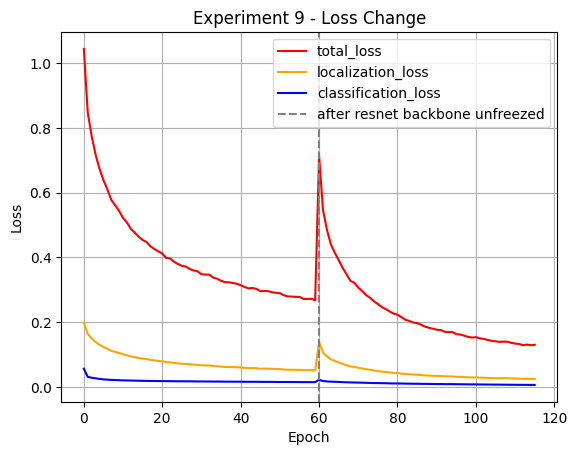

In [18]:
best_index = experiment9["val_f1"].idxmax()

total_loss_list1 = experiment9.loc[best_index, "total_loss_list1"]
classification_loss_list1 = experiment9.loc[best_index, "class_loss_list1"]
localization_loss_list1 = experiment9.loc[best_index, "localization_loss_list1"]

total_loss_list2 = experiment9.loc[best_index, "total_loss_list2"]
classification_loss_list2 = experiment9.loc[best_index, "class_loss_list2"]
localization_loss_list2 = experiment9.loc[best_index, "localization_loss_list2"]

total_loss_list = total_loss_list1 + total_loss_list2
localization_loss_list = localization_loss_list1 + localization_loss_list2
classification_loss_list = classification_loss_list1 + classification_loss_list2

epochs = range(len(total_loss_list))

plt.plot(epochs, total_loss_list, linestyle="-", color="red", label="total_loss")
plt.plot(epochs, localization_loss_list, linestyle="-", color="orange", label="localization_loss")
plt.plot(epochs, classification_loss_list, linestyle="-", color="blue", label="classification_loss")

plt.axvline(x=len(total_loss_list1), color='gray', linestyle='--', label="after resnet backbone unfreezed")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 9 - Loss Change")

plt.legend()
plt.grid()
plt.show()

In [21]:
print(total_loss_list[59])

0.26708892749850305


##### Experiment 10

In [8]:
# experiment 10

hyperparameter_combinations = {
    "detection_layers": [ [ [512, 256, 3, 1, 1, "zeros"], [256, 128, 3, 1, 1, "zeros"], [128, 64, 3, 1, 1, "zeros"] ] ],
    "activation_func": [nn.ReLU],
    "dropout_rate": [0.0],
    "positive_class_bce_coefficient": [0.5],
    "localization_loss_coefficent": [5],
    "bbox_loss_func": [nn.L1Loss],

    "fine_tune_layers_num": [2],

    "optimizer": [optim.AdamW],
    "optimizer_kwargs": [{"lr": 0.0001}],

    "first_max_num_epochs": [60],
    "second_max_num_epochs": [60],
    "patience": [3],

    "objectness_threshold": [0.10, 0.30, 0.50, 0.70, 0.90, 0.95],

    "batch_size": [16],

    "early_stop_step1": [False],
    
    "early_stop_step2": [True]
}

validate(train_set, validation_set, hyperparameter_combinations, True, "experiment_10.json", True, "experiment10_model")

combination validated


In [12]:
experiment10 = pd.read_json("experiment_10.json")

In [12]:

print("-------- experiment 9 -----------")
print(experiment9.loc[experiment9["val_f1"].idxmax(), val_metrics])

print("")

print("-------- experiment 10 -----------")
print(experiment10.loc[experiment10["val_f1"].idxmax(), val_metrics])

-------- experiment 9 -----------
val_precision    0.594526
val_recall       0.442356
val_f1           0.507275
val_mAP50        0.341661
Name: 2, dtype: object

-------- experiment 10 -----------
val_precision    0.610922
val_recall       0.448622
val_f1           0.517341
val_mAP50        0.356244
Name: 2, dtype: object


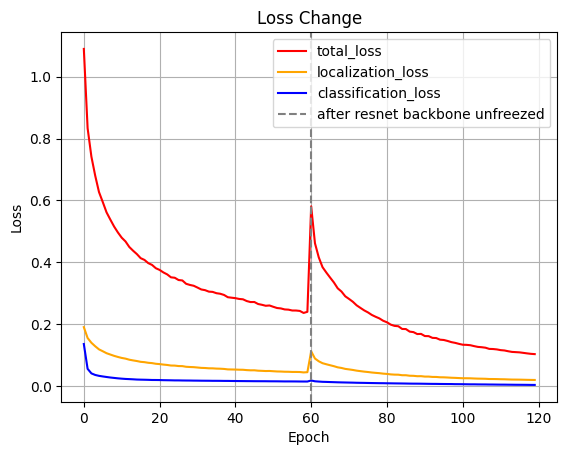

In [22]:
total_loss_list1 = experiment10.head(1)["total_loss_list1"].tolist()[0]
classification_loss_list1 = experiment10.head(1)["class_loss_list1"].tolist()[0]
localization_loss_list1 = experiment10.head(1)["localization_loss_list1"].tolist()[0]

total_loss_list2 = experiment10.head(1)["total_loss_list2"].tolist()[0]
classification_loss_list2 = experiment10.head(1)["class_loss_list2"].tolist()[0]
localization_loss_list2 = experiment10.head(1)["localization_loss_list2"].tolist()[0]

total_loss_list = total_loss_list1 + total_loss_list2
localization_loss_list = localization_loss_list1 + localization_loss_list2
classification_loss_list = classification_loss_list1 + classification_loss_list2

epochs = range(len(total_loss_list))

plt.plot(epochs, total_loss_list, linestyle="-", color="red", label="total_loss")
plt.plot(epochs, localization_loss_list, linestyle="-", color="orange", label="localization_loss")
plt.plot(epochs, classification_loss_list, linestyle="-", color="blue", label="classification_loss")

plt.axvline(x=len(total_loss_list1), color='gray', linestyle='--', label="after resnet backbone unfreezed")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Change")

plt.legend()
plt.grid()
plt.show()

In [23]:
print(total_loss_list[59])

0.240182986816374


#### experiment 11

In [9]:
# experiment 11

hyperparameter_combinations = {
    "detection_layers": [ [ [512, 256, 3, 1, 1, "zeros"], [256, 128, 3, 1, 1, "zeros"], [128, 64, 3, 1, 1, "zeros"] ] ],
    "activation_func": [nn.ReLU],
    "dropout_rate": [0.0],
    "positive_class_bce_coefficient": [0.5],
    "localization_loss_coefficent": [5],
    "bbox_loss_func": [nn.L1Loss],

    "fine_tune_layers_num": [2],

    "optimizer": [optim.AdamW],
    "optimizer_kwargs": [{"lr": 0.0001}],

    "first_max_num_epochs": [80],
    "second_max_num_epochs": [80],
    "patience": [3],

    "objectness_threshold": [0.10, 0.30, 0.50, 0.70, 0.90, 0.95],

    "batch_size": [16],

    "early_stop_step1": [False],
    
    "early_stop_step2": [True],

    "lr2": 0.00001
}

validate(train_set, validation_set, hyperparameter_combinations, True, "experiment_11.json", True, "experiment11_model", True)

combination validated


In [10]:
experiment11 = pd.read_json("experiment_11.json")

In [13]:

print("-------- experiment 10 -----------")
print(experiment10.loc[experiment10["val_f1"].idxmax(), val_metrics])


print("")


print("-------- experiment 11 -----------")
print(experiment11.loc[experiment11["val_f1"].idxmax(), val_metrics])

-------- experiment 10 -----------
val_precision    0.610922
val_recall       0.448622
val_f1           0.517341
val_mAP50        0.356244
Name: 2, dtype: object

-------- experiment 11 -----------
val_precision    0.554129
val_recall        0.31109
val_f1           0.398475
val_mAP50        0.208399
Name: 3, dtype: object


In [14]:

print("-------- experiment 10 -----------")
print(experiment10.loc[experiment10["val_f1"].idxmax(), train_metrics])


print("")


print("-------- experiment 11 -----------")
print(experiment11.loc[experiment11["val_f1"].idxmax(), train_metrics])

-------- experiment 10 -----------
train_precision    0.799195
train_recall       0.735747
train_f1            0.76616
train_mAP50          0.7004
Name: 2, dtype: object

-------- experiment 11 -----------
train_precision    0.859048
train_recall       0.615023
train_f1           0.716837
train_mAP50        0.638782
Name: 3, dtype: object


### Best Hyperparameter combination

In [16]:
print(experiment10.loc[experiment10["val_f1"].idxmax()])

detection_layers                  [[512, 256, 3, 1, 1, zeros], [256, 128, 3, 1, ...
activation_func                                                                ReLU
dropout_rate                                                                      0
positive_class_bce_coefficient                                                  0.5
localization_loss_coefficent                                                      5
bbox_loss_func                                                               L1Loss
fine_tune                                                                      True
fine_tune_layers_num                                                              2
optimizer                                                                     AdamW
optimizer_kwargs                                                     {'lr': 0.0001}
first_max_num_epochs                                                             60
second_max_num_epochs                                                       

In [18]:
print("-------- experiment 10 -----------")
print(experiment10.loc[experiment10["val_f1"].idxmax(), val_metrics])

-------- experiment 10 -----------
val_precision    0.610922
val_recall       0.448622
val_f1           0.517341
val_mAP50        0.356244
Name: 2, dtype: object


In [30]:

print("-------- 3 layer -----------")
print(experiment2.loc[experiment2["val_f1"].idxmax(), val_metrics])


print("")



print("-------- 2 layer -----------")
print(experiment3.loc[experiment3["val_f1"].idxmax(), val_metrics])


print("-------- 1 layer -----------")
exp_3_layer_1 = experiment3[experiment3["detection_layers"].apply(len) == 1]

print(exp_3_layer_1.loc[exp_3_layer_1["val_f1"].idxmax(), val_metrics])


-------- 3 layer -----------
val_precision    0.322376
val_recall       0.175125
val_f1           0.226959
val_mAP50        0.076175
Name: 5, dtype: object

-------- 2 layer -----------
val_precision    0.263444
val_recall       0.167293
val_f1           0.204637
val_mAP50        0.058601
Name: 15, dtype: object
-------- 1 layer -----------
val_precision    0.232921
val_recall       0.135652
val_f1           0.171451
val_mAP50        0.054946
Name: 3, dtype: object


In [32]:
print("-------- 2 layer -----------")
print(experiment1.loc[experiment1["val_f1"].idxmax(), val_metrics])

-------- 2 layer -----------
val_precision    0.277862
val_recall       0.172619
val_f1           0.212947
val_mAP50        0.065809
Name: 3, dtype: object
